# Info

- Objetivo: Fazer todo o préprocessamento, utilizando os dados do MTS para saber a rotação do pneu, e os dados do iTire. Extraíremos as características janelanto +/- 35° a partir do contact path a fim de modelar as forças do veículo como um modelo bicicleta.

- Dados de entrada: Acelerações Ax Ay Az do Pneu Inteligente
- Dados de saída: Fx Fy Fz da roda.

# Imports

In [3]:
import numpy as np 
import pandas as pd 
from scipy.signal import butter, filtfilt
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.stats import kurtosis
# import os
# from mggp import MGGP
# import time
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go
# import dash
# from dash import dcc, html
# import plotly.express as px
# from sklearn.metrics import mean_squared_error

from concurrent.futures import ProcessPoolExecutor

# Execute

In [2]:
# FOLDER = "Job1_2023_07_28_16_41_10_Mix"
# FOLDER = "Job1_2023_07_29_11_58_50_Mix"
FOLDER = "Job1_2023_07_29_11_41_22_Mix"

# FOLDER = "Job1_2023_07_29_11_36_05_Mix"
# FOLDER = "Job1_2023_07_29_11_46_44_Mix"
# FOLDER = 'Job1_2023_07_29_12_15_29_Mix'

## Functions

In [ ]:
def build_bicycle_model(input_path, output_path):
    path = f"E:\matlab files\iTire road test data\{FOLDER}\{input_path}.csv"
    df = pd.read_csv(path)

    df_RR = df[df['Pneu'] == 'RR'].drop('Pneu', axis=1).add_suffix('_RR')
    df_RL = df[df['Pneu'] == 'RL'].drop('Pneu', axis=1).add_suffix('_RL')
    df_FR = df[df['Pneu'] == 'FR'].drop('Pneu', axis=1).add_suffix('_FR')
    df_FL = df[df['Pneu'] == 'FL'].drop('Pneu', axis=1).add_suffix('_FL')

    df_full = pd.concat([df_RR.reset_index(drop=True), 
                        df_RL.reset_index(drop=True),
                        df_FR.reset_index(drop=True),
                        df_FL.reset_index(drop=True)], axis=1)

    df_medias = pd.DataFrame()

    features = [col for col in df.columns if col not in ['Pneu', 'Fx', 'Fy', 'Fz']]

    for feature in features:
        
        cols_R = [f"{feature}_RR", f"{feature}_RL"]
        df_medias[f"{feature}_R"] = df_full[cols_R].mean(axis=1)
        
        cols_F = [f"{feature}_FR", f"{feature}_FL"]
        df_medias[f"{feature}_F"] = df_full[cols_F].mean(axis=1)


    df_medias['Fx_R'] = df_full[['Fx_RR', 'Fx_RL']].mean(axis=1)
    df_medias['Fy_R'] = df_full[['Fy_RR', 'Fy_RL']].mean(axis=1)
    df_medias['Fz_R'] = df_full[['Fz_RR', 'Fz_RL']].mean(axis=1)

    df_medias['Fx_F'] = df_full[['Fx_FR', 'Fx_FL']].mean(axis=1)
    df_medias['Fy_F'] = df_full[['Fy_FR', 'Fy_FL']].mean(axis=1)
    df_medias['Fz_F'] = df_full[['Fz_FR', 'Fz_FL']].mean(axis=1)


    cols_order = [col for col in df_medias.columns if not col.startswith(('Fx_', 'Fy_', 'Fz_'))] + \
                ['Fx_R', 'Fy_R', 'Fz_R', 'Fx_F', 'Fy_F', 'Fz_F']
    df_medias = df_medias[cols_order]
    output_path_medias = f"E:\matlab files\iTire road test data\{FOLDER}\{output_path}.csv"

    df_medias = df_medias.dropna(axis=0)
    df_medias.to_csv(output_path_medias, index=False)

    print("Processamento concluído!")
    print(f"Arquivo com médias R e F salvo em: {output_path_medias}")
    print(f"\nDimensões do arquivo de médias: {df_medias.shape}")
    
def processar_intervalo(args):
    """
    Processa um único intervalo de dados para execução paralela.
    
    Args:
        args: Tupla contendo (intervalo, posicao_col, cols_v, cols_f, prefixo_pneu, degrees, resolution)
    
    Returns:
        Dicionário com features do intervalo
    """
    intervalo, posicao_col, cols_v, cols_f, prefixo_pneu, degrees, resolution = args
    
    if len(intervalo) < 2:
        return None
        
    features = {}
    
    for eixo, col in zip(['X', 'Y', 'Z'], cols_v):
        if col in intervalo.columns:
            if col != cols_v[0]:
                params = reduce_resolucion(intervalo[[posicao_col, col, cols_v[0]]], 
                                           posicao_col, 
                                           cols_v[0], 
                                           degrees=degrees,
                                           resolution=resolution)
            else:
                params = reduce_resolucion(intervalo[[posicao_col, cols_v[0]]], 
                                           posicao_col, 
                                           cols_v[0], 
                                           degrees=degrees,
                                           resolution=resolution)

            for j in range(len(params)):
                features.update({f'{eixo}_{j}': params[j]})

    if len(cols_f) >= 1:
        features['Fx'] = intervalo[cols_f[0]].mean()
    if len(cols_f) >= 2:
        features['Fy'] = intervalo[cols_f[1]].mean()
    if len(cols_f) >= 3:
        features['Fz'] = intervalo[cols_f[2]].mean()
    
    features['Pneu'] = prefixo_pneu
    
    return features

def processar_dados_pneu_paralelo(df, posicao_col, prefixo_pneu, degrees=35, resolution=2.5, max_workers=None):
    """
    Processa os dados de um pneu específico em paralelo usando ProcessPoolExecutor.
    
    Args:
        df: DataFrame com os dados
        posicao_col: Nome da coluna de degrees (RR_degrees, RL_degrees, etc.)
        prefixo_pneu: Prefixo do pneu (RR, RL, FR, FL) para identificar as colunas de força e velocidade
        max_workers: Número máximo de processos paralelos (None = usar todos os cores disponíveis)
        
    Returns:
        DataFrame com as features calculadas para cada intervalo de rotação
    """
    
    cols_v = [f'{prefixo_pneu}_X_V_', f'{prefixo_pneu}_Y_V_', f'{prefixo_pneu}_Z_V_']
    cols_f = [f'{prefixo_pneu}_X_Force_N_', 
              f'{prefixo_pneu}_Y_Force_N_',
              f'{prefixo_pneu}_Z_Force_N_']
    
    cols_v = [col for col in cols_v if col in df.columns]
    cols_f = [col for col in cols_f if col in df.columns]
        
    posicoes = df[posicao_col].values
    mudancas = np.where(np.diff(posicoes) < -300)[0] + 1
    
    intervalos = np.concatenate(([0], mudancas, [len(df)]))
    
    # Preparar argumentos para processamento paralelo
    args_list = []
    for i in range(len(intervalos)-2):
        inicio = intervalos[i+1]
        fim = intervalos[i+2]
        intervalo_df = df.iloc[inicio:fim]
        
        args_list.append((intervalo_df, posicao_col, cols_v, cols_f, prefixo_pneu, degrees, resolution))
    
    resultados = []
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = list(tqdm(executor.map(processar_intervalo, args_list), 
                           total=len(args_list), 
                           desc=f"Processando {prefixo_pneu}"))
        
        for future in futures:
            if future is not None:
                resultados.append(future)
    
    return pd.DataFrame(resultados)

def apply_butterworth_filter(signal, 
                             sample_rate = 10000, 
                             order=5, 
                             cutoff_freq = 400, 
                             type='low'):
    
    nyquist_freq = 0.5 * sample_rate
    normalized_cutoff = cutoff_freq / nyquist_freq

    b, a = butter(order, normalized_cutoff, btype=type, analog=False)
    return filtfilt(b, a, signal)


def calcular_features_pneu(signal, fs=10_000):
    """
    Calcula features específicas para dinâmica de pneu
    fs: taxa de amostragem (Hz)
    """
    n = len(signal)
    
    # Features de magnitude
    rms = np.sqrt(np.mean(signal**2))
    peak2peak = np.ptp(signal)
    kurt = kurtosis(signal)
    crest = np.max(np.abs(signal)) / rms if rms > 0 else 0
    
    # Features temporais
    mean_val = np.mean(signal)
    signal_centered = signal - mean_val
    mcr = len(np.where(np.diff(np.sign(signal_centered)))[0]) / n
    
    # Análise espectral para frequência dominante
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, 1/fs)
    dominant_freq = np.abs(freqs[np.argmax(np.abs(fft_vals[1:n//2]))])
    
    return [rms, peak2peak, kurt, crest, mcr, dominant_freq]


def calcular_features_selecionadas(signal):
    """
    Calcula 8 features selecionadas: 4 de magnitude (Y) e 4 temporais (X)
    
    Returns:
        list: Lista com os valores das 8 features na ordem:
              [RMS, Desvio_Padrao, Pico_a_Pico, Energia,
               MCR, Mean_IPI, Std_IPI, Temporal_Centroid]
    """

    n = len(signal)
    tempo = np.arange(n)  
    
    # ==================================================
    # 1. FEATURES DE MAGNITUDE (EIXO Y)
    # ==================================================
    
    rms = np.sqrt(np.mean(signal ** 2))
    desvio_padrao = np.std(signal)
    pico_a_pico = np.ptp(signal)
    energia = np.sum(signal ** 2)
    

    # ==================================================
    # 2. FEATURES TEMPORAIS (EIXO X)
    # ==================================================
    
    mean_val = np.mean(signal)
    signal_centered = signal - mean_val
    cruzamentos = np.where(np.diff(np.sign(signal_centered)))[0]
    mcr = len(cruzamentos) / n if n > 0 else 0
    
    picos, _ = find_peaks(signal, height=0.1*np.max(np.abs(signal)), prominence=0.1*np.std(signal))
    
    mean_ipi = 0
    std_ipi = 0
    
    if len(picos) >= 2:
        intervalos_picos = np.diff(picos)
        mean_ipi = np.mean(intervalos_picos)
        std_ipi = np.std(intervalos_picos)
    
    sinal_abs = np.abs(signal)
    soma_ponderada = np.sum(tempo * sinal_abs)
    soma_sinal = np.sum(sinal_abs)
    
    temporal_centroid = soma_ponderada / soma_sinal if soma_sinal > 0 else 0
    
    return [rms, desvio_padrao, pico_a_pico, energia, 
            mcr, mean_ipi, std_ipi, temporal_centroid]


def interpolate_angles(series, 
                       new_sample_rate = '100us'):
    radians = np.deg2rad(series)
    x = np.cos(radians)
    y = np.sin(radians)
    
    x_interp = x.resample(new_sample_rate).interpolate(method='linear')
    y_interp = y.resample(new_sample_rate).interpolate(method='linear')
    
    angles_interp = np.rad2deg(np.arctan2(y_interp, x_interp)) % 360
    return angles_interp


def reduce_resolucion(df: pd.DataFrame, 
                      posicao_col, 
                      acc_x,
                      resolution = 0.5, 
                      degrees = 35):
    
    # df[posicao_col] = round(df[posicao_col], 1)
    df = df.copy()
    df.loc[:, posicao_col] = round(df[posicao_col], 1)

    angulo_inicial = round(float(df[posicao_col].iloc[0]), 1)
    
    idx_min = df[acc_x].idxmin()
    idx_max = df[acc_x].idxmax()
    idx_med = round((idx_max - idx_min) / 2 + idx_min)

    ang_central = df.loc[idx_med, posicao_col]

    ang_inf = ang_central - degrees
    ang_sup = ang_central + degrees

    angulos_desejados = []
    angulo_atual = ang_inf
    while angulo_atual <= ang_sup:
        angulos_desejados.append(round(angulo_atual, 1))
        angulo_atual += resolution
        angulo_atual = round(angulo_atual, 1) 

    resultados = []
    for angulo in angulos_desejados:
        
        mask = (df[posicao_col] >= ang_inf) & (df[posicao_col] <= ang_sup)
        df_filtrado = df[mask].copy()
        
        if not df_filtrado.empty:
            # Com o arredondamento, aparece vários valores para um mesmo ângulo. 
            # Do jeito que está, ele pega o primeiro, mas se necessário, podemos futuramente fazer a média para cada ângulo, algo assim
            idx = (df_filtrado[posicao_col] - angulo).abs().idxmin()
            resultados.append(df_filtrado.loc[idx, df.columns[1]])

    return resultados


def processar_dados_pneu(df, posicao_col, prefixo_pneu, degrees=35, resolution=2.5):
    """
    Processa os dados de um pneu específico, identificando intervalos de 0-360 graus
    e calculando as features para cada intervalo.
    
    Args:
        df: DataFrame com os dados
        posicao_col: Nome da coluna de degrees (RR_degrees, RL_degrees, etc.)
        prefixo_pneu: Prefixo do pneu (RR, RL, FR, FL) para identificar as colunas de força e velocidade
        
    Returns:
        DataFrame com as features calculadas para cada intervalo de rotação
    """
    
    cols_v = [f'{prefixo_pneu}_X_V_', f'{prefixo_pneu}_Y_V_', f'{prefixo_pneu}_Z_V_']
    cols_f = [f'{prefixo_pneu}_X_Force_N_', 
              f'{prefixo_pneu}_Y_Force_N_',
              f'{prefixo_pneu}_Z_Force_N_']
    
    cols_v = [col for col in cols_v if col in df.columns]
    cols_f = [col for col in cols_f if col in df.columns]
        
    posicoes = df[posicao_col].values
    mudancas = np.where(np.diff(posicoes) < -300)[0] + 1
    
    intervalos = np.concatenate(([0], mudancas, [len(df)]))
    
    resultados = []
    
    for i in tqdm(range(len(intervalos)-2)):

        inicio = intervalos[i+1]
        fim = intervalos[i+2]
        
        intervalo = df.iloc[inicio:fim]
        
        if len(intervalo) < 2:
            continue
            
        features = {}
        for eixo, col in zip(['X', 'Y', 'Z'], cols_v):

            if col in df.columns:

                if col != cols_v[0]:
                    params = reduce_resolucion(intervalo[[posicao_col, col, cols_v[0]]], 
                                               posicao_col, 
                                               cols_v[0], 
                                               degrees = degrees,
                                               resolution=resolution)

                else:
                    params = reduce_resolucion(intervalo[[posicao_col, cols_v[0]]], 
                                               posicao_col, 
                                               cols_v[0], 
                                               degrees = degrees,
                                               resolution=resolution)

                for j in range(len(params)):
                    features.update({f'{eixo}_{j}': params[j]})     


        if len(cols_f) >= 1:
            features['Fx'] = intervalo[cols_f[0]].mean()
        if len(cols_f) >= 2:
            features['Fy'] = intervalo[cols_f[1]].mean()
        if len(cols_f) >= 3:
            features['Fz'] = intervalo[cols_f[2]].mean()
        
        features['Ax'] = intervalo['Ax'].mean()
        features['Ay'] = intervalo['Ay'].mean()
        features['SlipAng1le'] = intervalo['SlipAngle'].mean()
        
        features['Pneu'] = prefixo_pneu
        # features['Intervalo'] = i+1
        features['Initial_Time'] = intervalo['Time'].iloc[0]
        features['Final_Time'] = intervalo['Time'].iloc[-1]
        # features['Tamanho_Intervalo'] = len(intervalo)
        
        resultados.append(features)
    
    return pd.DataFrame(resultados)


def processar_arquivo(input_file, output_file, RT_data_resampled, degrees=35, resolution=2.5):
    df = pd.read_csv(input_file)

    df = pd.merge(RT_data_resampled, df, on='Time', how='inner')

    df = df.rename(columns={'LF_X_Force_N_': 'FL_X_Force_N_', 
                            'LF_Y_Force_N_': 'FL_Y_Force_N_',
                            'LF_Z_Force_N_': 'FL_Z_Force_N_',

                            'LR_X_Force_N_': 'RL_X_Force_N_', 
                            'LR_Y_Force_N_': 'RL_Y_Force_N_',
                            'LR_Z_Force_N_': 'RL_Z_Force_N_',

                            'RF_X_Force_N_': 'FR_X_Force_N_',
                            'RF_Y_Force_N_': 'FR_Y_Force_N_',
                            'RF_Z_Force_N_': 'FR_Z_Force_N_',})
    
    resultados_finais = []
    
    pneus = {
        'RR': 'RR_degrees',
        'RL': 'RL_degrees',
        'FR': 'FR_degrees',
        'FL': 'FL_degrees'
    }
    
    for prefixo, coluna_pos in pneus.items():
        if coluna_pos in df.columns:
            df_pneu = processar_dados_pneu(df, coluna_pos, prefixo, degrees=degrees, resolution=resolution)
            # df_pneu = processar_dados_pneu_paralelo(df, coluna_pos, prefixo, degrees=degrees, resolution=resolution, max_workers=14)
            resultados_finais.append(df_pneu)
    
    if resultados_finais:
        df_final = pd.concat(resultados_finais, ignore_index=True)
        df_final.to_csv(output_file, index=False)
        
        print(f"Arquivo processado com sucesso. Resultados salvos em {output_file}")
        return df_final
    
    else:
        print("Nenhum dado foi processado. Verifique as colunas de entrada.")
        return None

## MTS

In [33]:
path = f'E:\matlab files\iTire road test data\{FOLDER}\MTS_data.csv'

MTS_data = pd.read_csv(path)
MTS_data = MTS_data.rename(columns={'Time__1___default_sample_rate_s_': 'Time'})

cols = ['Time', 
        'RR_Position_degrees_', 'LR_Position_degrees_',
        'RF_Position_degrees_', 'LF_Position_degrees_',
        'LF_X_Force_N_', 'LF_Y_Force_N_', 'LF_Z_Force_N_',
        'LR_X_Force_N_', 'LR_Y_Force_N_', 'LR_Z_Force_N_',
        'RF_X_Force_N_', 'RF_Y_Force_N_', 'RF_Z_Force_N_',
        'RR_X_Force_N_', 'RR_Y_Force_N_', 'RR_Z_Force_N_']

MTS_data = MTS_data[cols]
df = MTS_data[cols].copy()

df['Time'] = pd.to_timedelta(df['Time'], unit='s')
df = df.set_index('Time')

angle_cols = ['RR_Position_degrees_', 'LR_Position_degrees_', 
              'RF_Position_degrees_', 'LF_Position_degrees_']

MTS_data_resampled = pd.DataFrame()

new_sample_rate = '100us'

non_angle_cols = [col for col in cols if col not in angle_cols and col != 'Time']
for col in non_angle_cols:
    MTS_data_resampled[col] = df[col].resample(new_sample_rate).interpolate(method='linear')

for col in angle_cols:
    MTS_data_resampled[col] = interpolate_angles(df[col])


MTS_data_resampled = MTS_data_resampled.reset_index()
MTS_data_resampled['Time'] = MTS_data_resampled['Time'].dt.total_seconds()

MTS_data_resampled = MTS_data_resampled[cols]



## iTire and Merge with MTS data

In [34]:
path = f"E:\matlab files\iTire road test data\{FOLDER}\iTire_data.csv"
iTire_data = pd.read_csv(path)

iTire_data[['Time__1___fast_sample_rate_s_']] = round(iTire_data[['Time__1___fast_sample_rate_s_']], 4)
iTire_data = iTire_data.rename(columns={'Time__1___fast_sample_rate_s_': 'Time'})

iTire_data = iTire_data[['Time', 
             'FL_X_V_', 'FL_Y_V_', 'FL_Z_V_', 
             'FR_X_V_', 'FR_Y_V_', 'FR_Z_V_',
             'RL_X_V_', 'RL_Y_V_', 'RL_Z_V_',
             'RR_X_V_', 'RR_Y_V_', 'RR_Z_V_']]

forces_names = ['FL_X_V_', 'FL_Y_V_', 'FL_Z_V_', 
                'FR_X_V_', 'FR_Y_V_', 'FR_Z_V_',
                'RL_X_V_', 'RL_Y_V_', 'RL_Z_V_',
                'RR_X_V_', 'RR_Y_V_', 'RR_Z_V_']

for name in forces_names:
    iTire_data[name] = apply_butterworth_filter(iTire_data[name])

In [35]:
merged_data = pd.merge(MTS_data_resampled, iTire_data, on='Time', how='inner')

merged_data = merged_data.rename(columns={'RR_Position_degrees_': 'RR_degrees', 
                                          'LR_Position_degrees_': 'RL_degrees',
                                          'RF_Position_degrees_': 'FR_degrees', 
                                          'LF_Position_degrees_': 'FL_degrees'})

path = f'E:\matlab files\iTire road test data\{FOLDER}\iTire_MTS_merged_with_Fz.csv'
merged_data.to_csv(path, index=False)

## Extract Features for Each Tire

In [ ]:
folders = [
            # 'Job1_2023_07_29_12_15_29_Mix',
            "Job1_2023_07_29_11_36_05_Mix",
            "Job1_2023_07_29_11_41_22_Mix",
            # "Job1_2023_07_29_11_58_50_Mix",
            # "Job1_2023_07_29_11_46_44_Mix",
            # "Job1_2023_07_28_16_41_10_Mix",
            ]

for FOLDER in folders:
    number = '20_25'
    input_file = f'iTire road test data/{FOLDER}/iTire_MTS_merged_with_Fz.csv'
    output_file = f"iTire road test data/{FOLDER}/Tire_Features_extraidas_slip_{number}.csv"

    path_rt = f'E:\matlab files\iTire road test data\{FOLDER}\RT_data.csv'
    RT_data = pd.read_csv(path_rt)
    RT_data = RT_data.rename(columns={
                                    'ch_IsoVsLongitudinalVelocity_m_s_': 'Vx', 
                                    'ch_IsoVsLateralVelocity_m_s_': 'Vy', 
                                    'ch_AngleSlip____': 'SlipAngle',
                                    'ch_IsoVsLateralAcceleration_m_s___': 'Ay', 
                                    'ch_IsoVsLongitudinalAcceleration_m_s___': 'Ax',
                                    'A_time_ms_': 'Time'
                                    })

    # cols = ['Time', 'Vx', 'Vy', 'Ax', 'Ay', 'SlipAngle']
    cols = ['Time', 'Ax', 'Ay', 'SlipAngle']
    RT_data = RT_data[cols]

    # RT_data['Vx'] = RT_data['Vx'] * 3.6
    # RT_data['Vy'] = RT_data['Vy'] * 3.6

    RT_data['Time'] = pd.to_timedelta(RT_data['Time'], unit='s')
    RT_data = RT_data.set_index('Time')
    RT_data_resampled = pd.DataFrame()
    new_sample_rate = '100us'

    for col in RT_data.columns:
        RT_data_resampled[col] = RT_data[col].resample(new_sample_rate).interpolate(method='linear')

    RT_data_resampled = RT_data_resampled.reset_index()
    RT_data_resampled['Time'] = RT_data_resampled['Time'].dt.total_seconds()

    RT_data_resampled = RT_data_resampled[cols]

    df_resultado = processar_arquivo(input_file, output_file, RT_data_resampled, degrees=10, resolution=2.5)

    input_path = f'Tire_Features_extraidas_slip_{number}'
    output_path = f'Tire_Features_medias_R_F_with_Fz_slip_{number}'

    # build_bicycle_model(input_path, output_path)

100%|██████████| 3551/3551 [01:05<00:00, 54.11it/s]


Arquivo processado com sucesso. Resultados salvos em E:\matlab files\iTire road test data\Job1_2023_07_29_11_36_05_Mix\Tire_Features_extraidas_slip_35_25.csv


100%|██████████| 1210/1210 [00:22<00:00, 53.58it/s]


Arquivo processado com sucesso. Resultados salvos em E:\matlab files\iTire road test data\Job1_2023_07_29_11_41_22_Mix\Tire_Features_extraidas_slip_35_25.csv


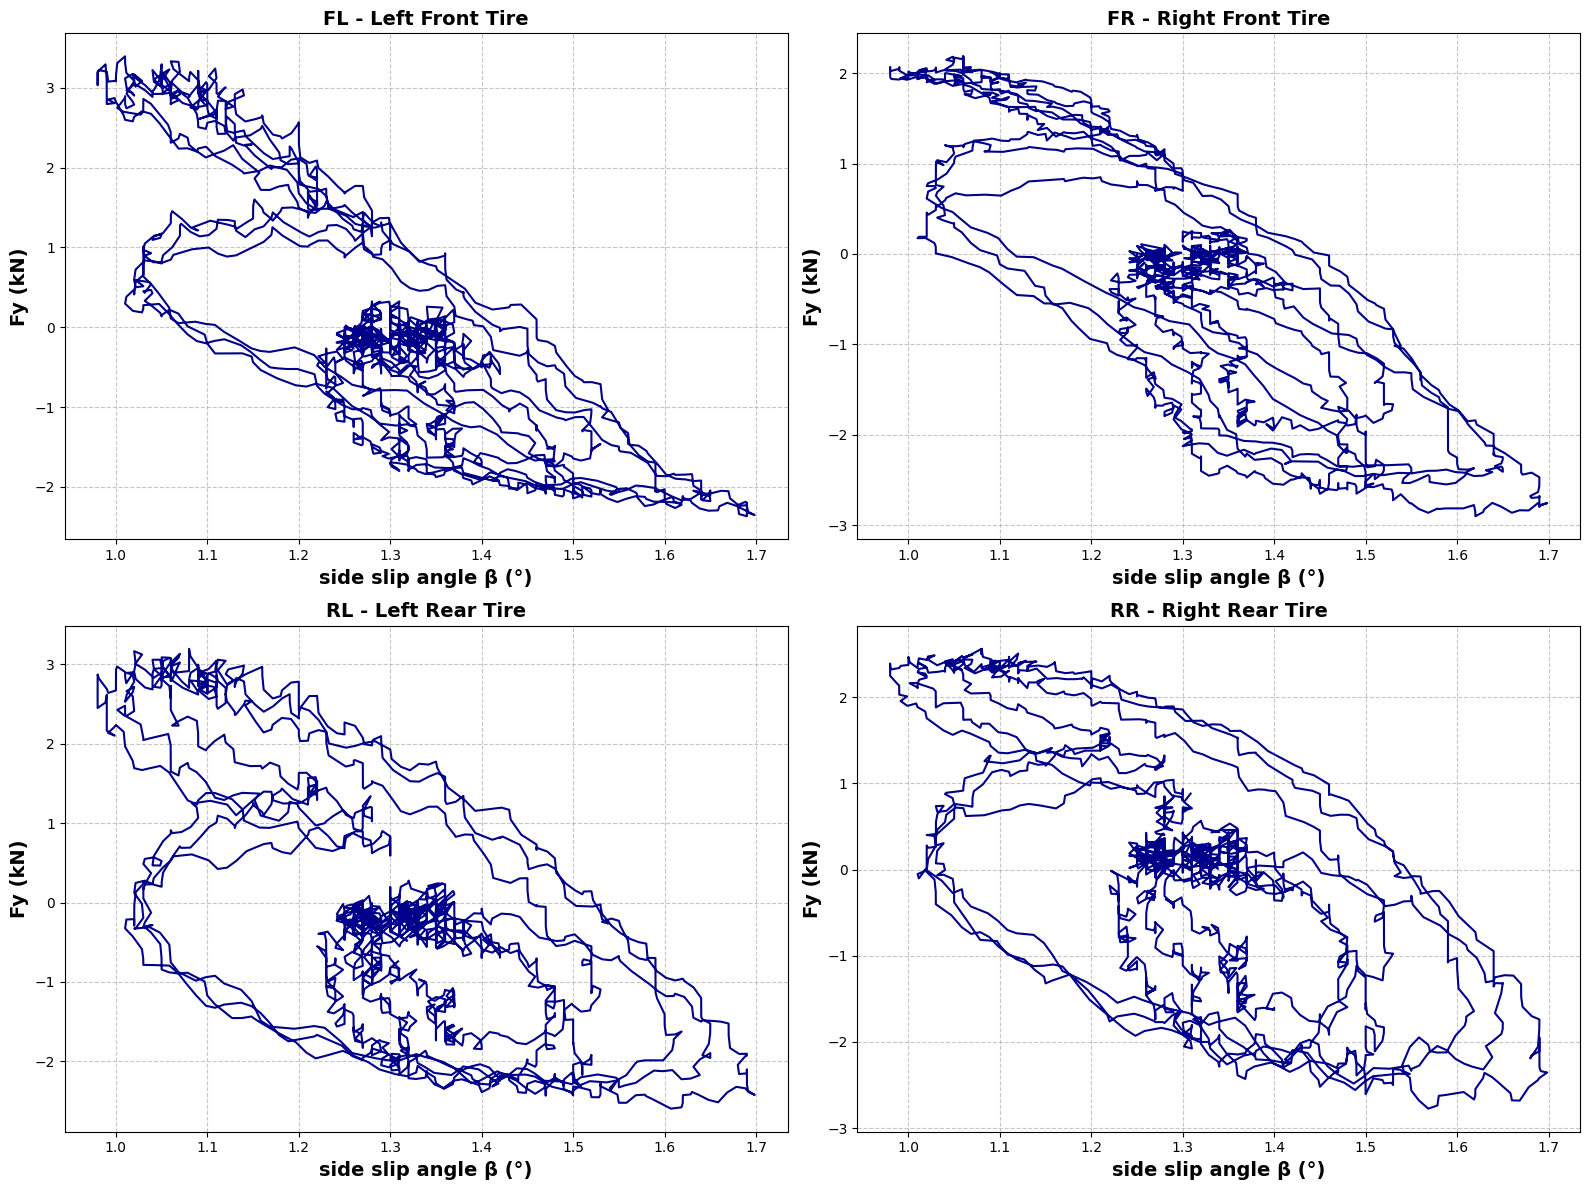

In [54]:
FOLDER = "Job1_2023_07_29_11_41_22_Mix"
path_rt = f'E:\matlab files\iTire road test data\{FOLDER}\RT_data.csv'
RT_data = pd.read_csv(path_rt)
RT_data = RT_data.rename(columns={
                                'ch_IsoVsLongitudinalVelocity_m_s_': 'Vx', 
                                'ch_IsoVsLateralVelocity_m_s_': 'Vy', 
                                'ch_AngleSlip____': 'SlipAngle',
                                'ch_IsoVsLateralAcceleration_m_s___': 'Ay', 
                                'ch_IsoVsLongitudinalAcceleration_m_s___': 'Ax',
                                'A_time_ms_': 'Time'
                                })

# cols = ['Time', 'Vx', 'Vy', 'Ax', 'Ay', 'SlipAngle']
cols = ['Time', 'Ax', 'Ay', 'SlipAngle']
RT_data = RT_data[cols]
RT_data

RT_data['Time'] = pd.to_timedelta(RT_data['Time'], unit='s')
RT_data = RT_data.set_index('Time')
RT_data_resampled = pd.DataFrame()
new_sample_rate = '100us'

for col in RT_data.columns:
    RT_data_resampled[col] = RT_data[col].resample(new_sample_rate).interpolate(method='linear')

RT_data_resampled = RT_data_resampled.reset_index()
RT_data_resampled['Time'] = RT_data_resampled['Time'].dt.total_seconds()

RT_data_resampled = RT_data_resampled[cols]

df = pd.read_csv(f'E:\matlab files\iTire road test data\{FOLDER}\iTire_MTS_merged_with_Fz.csv')

df = pd.merge(RT_data_resampled, df, on='Time', how='inner')

df = df.rename(columns={'LF_X_Force_N_': 'FL_X_Force_N_', 
                        'LF_Y_Force_N_': 'FL_Y_Force_N_',
                        'LF_Z_Force_N_': 'FL_Z_Force_N_',

                        'LR_X_Force_N_': 'RL_X_Force_N_', 
                        'LR_Y_Force_N_': 'RL_Y_Force_N_',
                        'LR_Z_Force_N_': 'RL_Z_Force_N_',

                        'RF_X_Force_N_': 'FR_X_Force_N_',
                        'RF_Y_Force_N_': 'FR_Y_Force_N_',
                        'RF_Z_Force_N_': 'FR_Z_Force_N_',})

import matplotlib.pyplot as plt

# Criar figura com subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle('Forças Laterais vs Ângulo de Deriva', fontsize=16, y=1.02)

# Dados de intervalo
start_idx = 1_970_000
end_idx = 2_200_000
x_data = df['SlipAngle'].values[start_idx:end_idx]

# RR (Right Rear)
axes[1, 1].plot(x_data, df['RR_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[1, 1].set_title('RR - Right Rear Tire', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

# RL (Left Rear)
axes[1, 0].plot(x_data, df['RL_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[1, 0].set_title('RL - Left Rear Tire', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# FR (Right Front)
axes[0, 1].plot(x_data, df['FR_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[0, 1].set_title('FR - Right Front Tire', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# FL (Left Front)
axes[0, 0].plot(x_data, df['FL_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[0, 0].set_title('FL - Left Front Tire', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Ajustar layout para evitar sobreposição
plt.tight_layout()
plt.show()

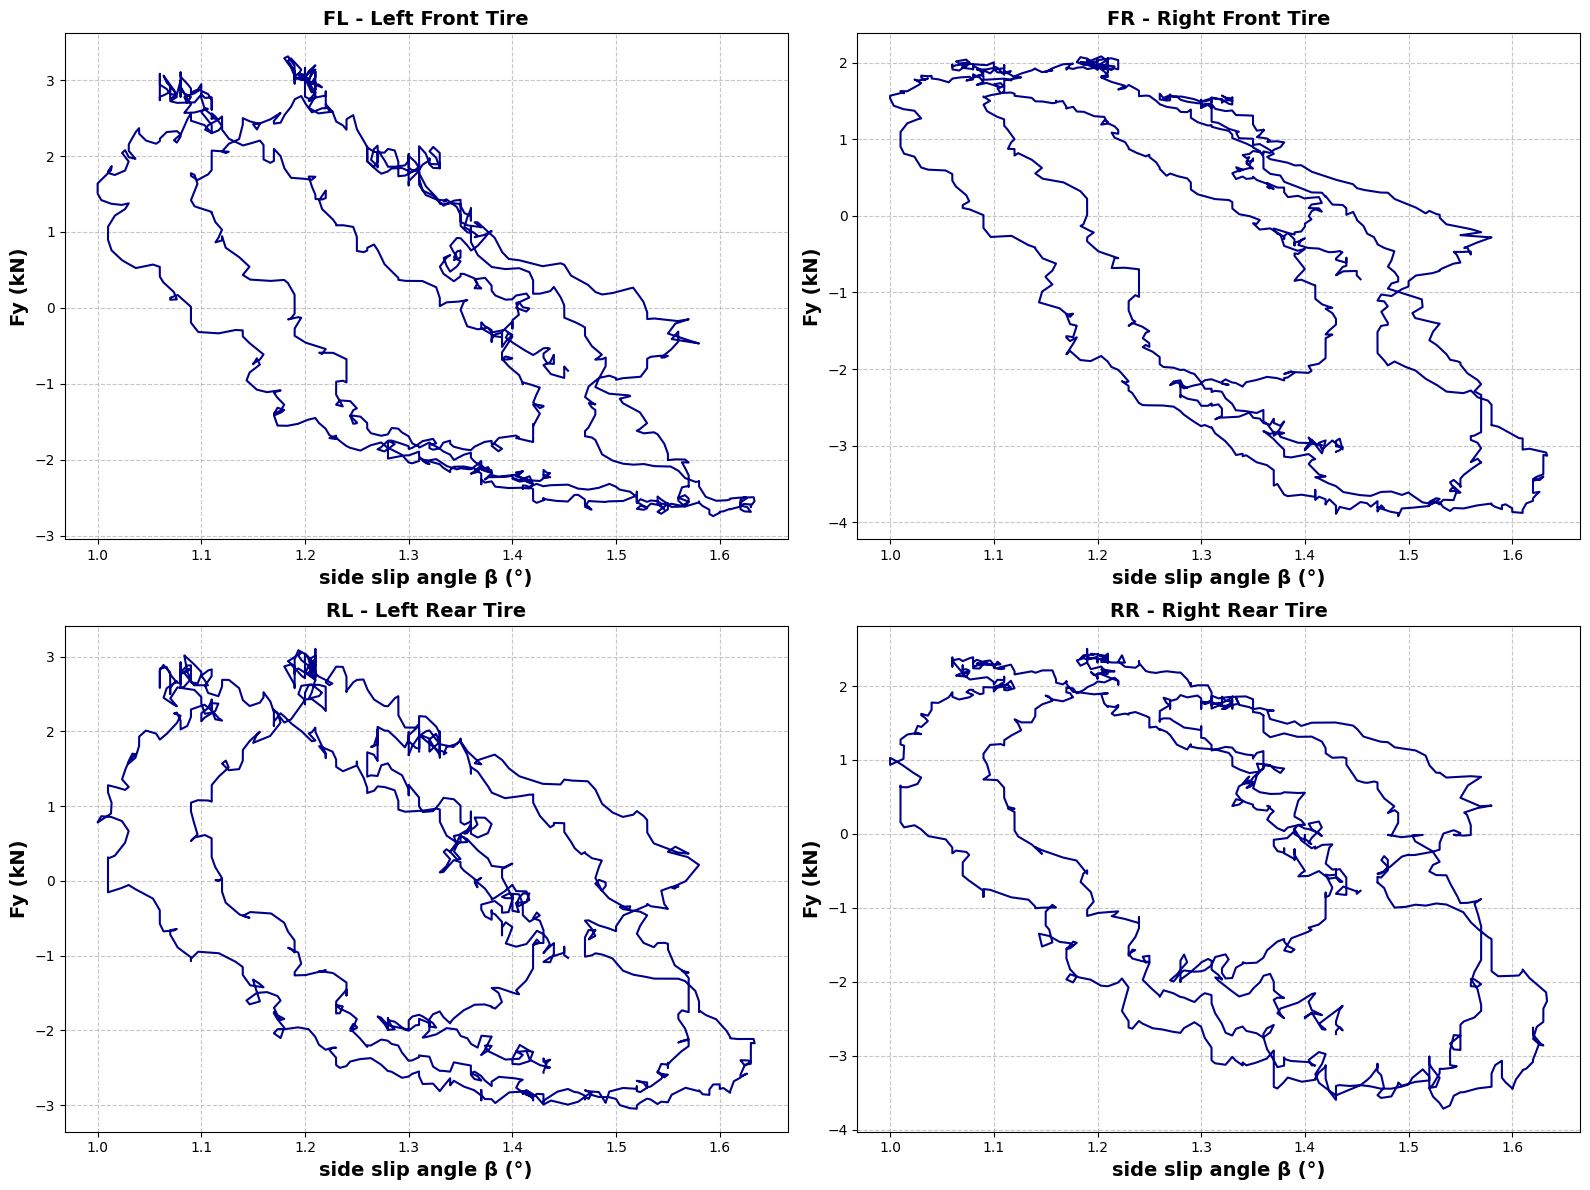

In [52]:
FOLDER = "Job1_2023_07_29_11_36_05_Mix"
path_rt = f'E:\matlab files\iTire road test data\{FOLDER}\RT_data.csv'
RT_data = pd.read_csv(path_rt)
RT_data = RT_data.rename(columns={
                                'ch_IsoVsLongitudinalVelocity_m_s_': 'Vx', 
                                'ch_IsoVsLateralVelocity_m_s_': 'Vy', 
                                'ch_AngleSlip____': 'SlipAngle',
                                'ch_IsoVsLateralAcceleration_m_s___': 'Ay', 
                                'ch_IsoVsLongitudinalAcceleration_m_s___': 'Ax',
                                'A_time_ms_': 'Time'
                                })

# cols = ['Time', 'Vx', 'Vy', 'Ax', 'Ay', 'SlipAngle']
cols = ['Time', 'Ax', 'Ay', 'SlipAngle']
RT_data = RT_data[cols]

RT_data['Time'] = pd.to_timedelta(RT_data['Time'], unit='s')
RT_data = RT_data.set_index('Time')
RT_data_resampled = pd.DataFrame()
new_sample_rate = '100us'

for col in RT_data.columns:
    RT_data_resampled[col] = RT_data[col].resample(new_sample_rate).interpolate(method='linear')

RT_data_resampled = RT_data_resampled.reset_index()
RT_data_resampled['Time'] = RT_data_resampled['Time'].dt.total_seconds()

RT_data_resampled = RT_data_resampled[cols]

df = pd.read_csv(f'E:\matlab files\iTire road test data\{FOLDER}\iTire_MTS_merged_with_Fz.csv')

df = pd.merge(RT_data_resampled, df, on='Time', how='inner')

df = df.rename(columns={'LF_X_Force_N_': 'FL_X_Force_N_', 
                        'LF_Y_Force_N_': 'FL_Y_Force_N_',
                        'LF_Z_Force_N_': 'FL_Z_Force_N_',

                        'LR_X_Force_N_': 'RL_X_Force_N_', 
                        'LR_Y_Force_N_': 'RL_Y_Force_N_',
                        'LR_Z_Force_N_': 'RL_Z_Force_N_',

                        'RF_X_Force_N_': 'FR_X_Force_N_',
                        'RF_Y_Force_N_': 'FR_Y_Force_N_',
                        'RF_Z_Force_N_': 'FR_Z_Force_N_',})

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle('Forças Laterais vs Ângulo de Deriva', fontsize=16, y=1.02)

start_idx = 5_520_000
end_idx = 5_635_000
x_data = df['SlipAngle'].values[start_idx:end_idx]

# RR (Right Rear)
axes[1, 1].plot(x_data, df['RR_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[1, 1].set_title('RR - Right Rear Tire', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

# RL (Left Rear)
axes[1, 0].plot(x_data, df['RL_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[1, 0].set_title('RL - Left Rear Tire', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# FR (Right Front)
axes[0, 1].plot(x_data, df['FR_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[0, 1].set_title('FR - Right Front Tire', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# FL (Left Front)
axes[0, 0].plot(x_data, df['FL_Y_Force_N_'].values[start_idx:end_idx]/1000, color='darkblue')
axes[0, 0].set_title('FL - Left Front Tire', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('side slip angle β (°)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Fy (kN)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()